In [1]:
%pip install ydata_profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Import libraries
2. Load CSV files
3. Inspect tables
4. Create unified interactions table
5. Data quality checks
6. Clean invalid rows
7. Basic volume statistics
8. Sparsity and ALS readiness
9. User activity and cold-start
10. Discount popularity and long-tail
11. Interaction funnel and weights
12. Category, role, and location analysis
13. Time-based analysis
14. Model readiness summary
15. Data Quality Report for Wiki

#### 1&2 Import Libraries and Load Data



In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt

C:\Users\Seidahmet\AppData\Local\Temp\ipykernel_31400\2734375067.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [3]:
path = Path("../data/raw/")

users_df = pd.read_csv(path / "users.csv")
categories_df = pd.read_csv(path / "categories_.csv")
category_discount_df = pd.read_csv( path / "category_discount_.csv")
countries_df = pd.read_csv(path / "countries_.csv")
discount_button_click_statistics_df = pd.read_csv(path / "discount_button_click_statistics_.csv")
discount_favourites_df = pd.read_csv(path / "discount_favourites_.csv")
discount_rates_df = pd.read_csv(path / "discount_rates_.csv")
discounts_df = pd.read_csv(path / "discounts.csv")
localization_default_df = pd.read_csv(path / "localization_default_.csv")
location_discount_df = pd.read_csv(path / "location_discount_.csv")
locations_df = pd.read_csv(path / "locations_.csv")
roles_df = pd.read_csv(path / "roles_.csv")
users_assigned_locations_df = pd.read_csv(path / "users_assigned_locations_.csv")

### Brief Introduction
users.csv → user information

discounts.csv → discount/item information

discount_button_click_statistics_.csv → click/show interaction events

discount_favourites_.csv → favourite events

discount_rates_.csv → like/dislike events

category_discount_.csv → discount-category relation

location_discount_.csv → discount-location relation

roles_.csv → role names

locations_.csv → location IDs

In [4]:
tables = {
    "users": users_df,
    "categories": categories_df,
    "category_discount": category_discount_df,
    "countries": countries_df,
    "discount_button_click_statistics": discount_button_click_statistics_df,
    "discount_favourites": discount_favourites_df,
    "discount_rates": discount_rates_df,
    "discounts": discounts_df,
    "localization_default": localization_default_df,
    "location_discount": location_discount_df,
    "locations": locations_df,
    "roles": roles_df,
    "users_assigned_locations": users_assigned_locations_df
}

### 3.Inspect Tables

In [5]:
def dataset_overview(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst rows:")
    display(df.head())
    print("\nMissing values:")
    display(df.isna().sum().sort_values(ascending=False))
    print("\nDuplicates:", df.duplicated().sum())



In [6]:
for name,df in tables.items():
  dataset_overview(df,name)


===== users =====
Shape: (4891, 13)

Columns:
['id', 'role_id', 'login', 'last_visited_location_id', 'banner_closed', 'email', 'password', 'first_name', 'last_name', 'location', 'is_a_player', 'created_at', 'updated_at']

Data types:
id                            int64
role_id                       int64
login                        object
last_visited_location_id    float64
banner_closed                  bool
email                        object
password                     object
first_name                   object
last_name                    object
location                    float64
is_a_player                    bool
created_at                   object
updated_at                   object
dtype: object

First rows:


,id,role_id,login,last_visited_location_id,banner_closed,email,password,first_name,last_name,location,is_a_player,created_at,updated_at
0,1814,3,k.balabanova@andersenlab.com,NaN,False,k.balabanova@andersenlab.com,NaN,NaN,NaN,NaN,False,2026-05-11 16:09:30.864 +0500,2026-05-11 16:09:30.864 +0500
1,1828,3,m.kovalchuk@andersenlab.com,NaN,False,m.kovalchuk@andersenlab.com,NaN,NaN,NaN,NaN,False,2026-05-11 16:09:30.864 +0500,2026-05-11 16:09:30.864 +0500
2,2959,3,r.galiamshin@andersenlab.com,NaN,False,r.galiamshin@andersenlab.com,NaN,NaN,NaN,NaN,False,2026-05-11 16:09:30.864 +0500,2026-05-11 16:09:30.864 +0500
3,3266,3,t.nasibli@andersenlab.com,NaN,False,t.nasibli@andersenlab.com,NaN,NaN,NaN,NaN,False,2026-05-11 16:09:30.864 +0500,2026-05-11 16:09:30.864 +0500
4,5033,3,a.bulakhov@andersenlab.com,NaN,False,a.bulakhov@andersenlab.com,NaN,NaN,NaN,NaN,False,2026-05-11 16:09:30.864 +0500,2026-05-11 16:09:30.864 +0500



Missing values:


location                    4891
password                    3860
first_name                  3748
last_name                   3748
last_visited_location_id     979
email                         28
id                             0
role_id                        0
login                          0
banner_closed                  0
is_a_player                    0
created_at                     0
updated_at                     0
dtype: int64


Duplicates: 0

===== categories =====
Shape: (12, 5)

Columns:
['id', 'title', 'icon_link', 'created_at', 'updated_at']

Data types:
id             int64
title         object
icon_link     object
created_at    object
updated_at    object
dtype: object

First rows:


...


Duplicates: 0

===== users_assigned_locations =====
Shape: (19, 2)

Columns:
['user_id', 'location_id']

Data types:
user_id        int64
location_id    int64
dtype: object

First rows:


,user_id,location_id
0,2372,50
1,2372,60
2,5156,17
3,46,43
4,46,44



Missing values:


user_id        0
location_id    0
dtype: int64


Duplicates: 0


In [7]:
summary_rows = []
for name,df in tables.items():
    summary_rows.append({
        'table_name':name,
        'n_rows':df.shape[0],
        'n_columns':df.shape[1],
        'duplicates':df.duplicated().sum(),
        'missing_total':df.isna().sum()
    })

tables_summary = pd.DataFrame(summary_rows)

In [8]:
tables_summary

,table_name,n_rows,n_columns,duplicates,missing_total
0,users,4891,13,0,id 0 role_id ...
1,categories,12,5,0,id 0 title 0 icon_link ...
2,category_discount,1161,3,0,id 0 category_id 0 discount_id ...
3,countries,12,4,0,id 0 localization_defa...
4,discount_button_click_statistics,32138,8,0,id 0 statistics_type 0 disc...
5,discount_favourites,1652,5,0,id 0 discount_id 0 user_id ...
6,discount_rates,1546,7,0,id 0 discount_id 0 user_i...
7,discounts,1016,18,0,id 0 company_id ...
8,localization_default,231,4,0,id 0 localization_text 0 ...
9,location_discount,5697,3,0,id 0 location_id 0 discount_id ...


In [9]:
for name,df in tables.items():
    print(f'Name:{name}')
    print(f'Column Names:{df.columns.tolist()}')

Name:users
Column Names:['id', 'role_id', 'login', 'last_visited_location_id', 'banner_closed', 'email', 'password', 'first_name', 'last_name', 'location', 'is_a_player', 'created_at', 'updated_at']
Name:categories
Column Names:['id', 'title', 'icon_link', 'created_at', 'updated_at']
Name:category_discount
Column Names:['id', 'category_id', 'discount_id']
Name:countries
Column Names:['id', 'localization_default_id', 'created_at', 'updated_at']
Name:discount_button_click_statistics
Column Names:['id', 'statistics_type', 'discount_id', 'name', 'user_id', 'time_create', 'location_id', 'role_id']
Name:discount_favourites
Column Names:['id', 'discount_id', 'user_id', 'created_at', 'updated_at']
Name:discount_rates
Column Names:['id', 'discount_id', 'user_id', 'rate_type', 'comment', 'created_at', 'updated_at']
Name:discounts
Column Names:['id', 'company_id', 'type', 'discount_condition', 'discount_type', 'start_date', 'end_date', 'image', 'size_min', 'size_max', 'like_count', 'dislike_count

## 4. Create Unified Interactions Table


interactions = click_events + favourite_events  + rating_events
                            ////
user_id + item_id + interaction_type + time + weight


Each row represents one user action toward one discount item.

The table will be used to calculate interaction volume, sparsity, cold-start users/items, popularity bias, and ALS readiness.

The original data stores user actions in separate tables: button clicks, favourites, and ratings. 

For recommender-system EDA, these actions are combined into one unified interaction table.

In [10]:
click_events = discount_button_click_statistics_df.copy()

click_events.columns

Index(['id', 'statistics_type', 'discount_id', 'name', 'user_id',
       'time_create', 'location_id', 'role_id'],
      dtype='object')

In [11]:
click_events['name'].value_counts()
click_events['name']

0        SHOW_AT_LOCATION
1        SHOW_AT_LOCATION
2        SHOW_AT_LOCATION
3        SHOW_AT_LOCATION
4        SHOW_AT_LOCATION
               ...       
32133           OPEN_CARD
32134           OPEN_CARD
32135           OPEN_CARD
32136           OPEN_CARD
32137           OPEN_CARD
Name: name, Length: 32138, dtype: object

In [12]:
click_events['statistics_type'].value_counts()
click_events['statistics_type']

0        DISCOUNTS
1        DISCOUNTS
2        DISCOUNTS
3        DISCOUNTS
4        DISCOUNTS
           ...    
32133    DISCOUNTS
32134    DISCOUNTS
32135    DISCOUNTS
32136    DISCOUNTS
32137    DISCOUNTS
Name: statistics_type, Length: 32138, dtype: object

In [13]:
click_events['event_type'] = click_events['name']
click_events['event_time'] = click_events['time_create']
click_events['source_table'] = "discount_button_click_statistics"

In [14]:
click_events['interaction_weight'] = click_events['event_type'].map({
    'SHOW_AT_LOCATION':0.1,
    'OPEN_CARD':0.3,
    'GET_A_PROMOCODE':2,
})

In [15]:
click_events["event_type"].value_counts()
click_events["interaction_weight"].isna().sum()
click_events.head()

,id,statistics_type,discount_id,name,user_id,time_create,location_id,role_id,event_type,event_time,source_table,interaction_weight
0,1,DISCOUNTS,17,SHOW_AT_LOCATION,1535,2025-01-16 15:18:53.386,16,3,SHOW_AT_LOCATION,2025-01-16 15:18:53.386,discount_button_click_statistics,0.1
1,2,DISCOUNTS,522,SHOW_AT_LOCATION,9,2025-01-16 15:39:03.441,16,3,SHOW_AT_LOCATION,2025-01-16 15:39:03.441,discount_button_click_statistics,0.1
2,3,DISCOUNTS,5,SHOW_AT_LOCATION,1455,2025-01-16 17:59:54.167,16,3,SHOW_AT_LOCATION,2025-01-16 17:59:54.167,discount_button_click_statistics,0.1
3,4,DISCOUNTS,2,SHOW_AT_LOCATION,1455,2025-01-16 18:00:05.394,16,3,SHOW_AT_LOCATION,2025-01-16 18:00:05.394,discount_button_click_statistics,0.1
4,5,DISCOUNTS,11,SHOW_AT_LOCATION,1418,2025-01-16 19:02:26.925,16,3,SHOW_AT_LOCATION,2025-01-16 19:02:26.925,discount_button_click_statistics,0.1


In [16]:
click_events = click_events[['user_id','discount_id','event_type','event_time','interaction_weight','source_table','location_id','role_id']]

In [17]:
click_events["interaction_weight"].isna().sum()

0

In [18]:
favourite_events = discount_favourites_df.copy()

favourite_events['event_type'] = 'FAVOURITE'
favourite_events['event_time'] = favourite_events['created_at']
favourite_events['source_table'] = 'discount_favourites'
favourite_events['interaction_weight'] = 4.0


In [19]:
favourite_events['location_id'] = np.nan
favourite_events['role_id'] = np.nan

In [20]:
favourite_events = favourite_events[[
    'user_id',
    'discount_id',
    'event_type',
    'event_time',
    'interaction_weight',
    'source_table',
    'location_id',
    'role_id',
]]

In [21]:
favourite_events.head()

,user_id,discount_id,event_type,event_time,interaction_weight,source_table,location_id,role_id
0,2907,1199,FAVOURITE,2026-05-11 16:09:30.921 +0500,4.0,discount_favourites,NaN,NaN
1,2907,1131,FAVOURITE,2026-05-11 16:09:30.921 +0500,4.0,discount_favourites,NaN,NaN
2,5293,823,FAVOURITE,2026-05-11 16:09:30.921 +0500,4.0,discount_favourites,NaN,NaN
3,1517,589,FAVOURITE,2026-05-11 16:09:30.921 +0500,4.0,discount_favourites,NaN,NaN
4,1045,725,FAVOURITE,2026-05-11 16:09:30.921 +0500,4.0,discount_favourites,NaN,NaN


In [22]:
rating_events = discount_rates_df.copy()


In [23]:
rating_events['event_type'] = rating_events['rate_type']
rating_events['event_time'] = rating_events['created_at']
rating_events['source_table'] = 'discount_rates'

In [24]:
rating_events.head(3)

,id,discount_id,user_id,rate_type,comment,created_at,updated_at,event_type,event_time,source_table
0,1319,242,741,LIKE,NaN,2025-08-07 12:23:19.861,2026-05-11 16:09:30.986 +0500,LIKE,2025-08-07 12:23:19.861,discount_rates
1,43,26,25,LIKE,NaN,2025-01-01 00:00:00.000,2026-05-11 16:09:30.986 +0500,LIKE,2025-01-01 00:00:00.000,discount_rates
2,638,357,9,DISLIKE,Test Comment,2025-01-01 00:00:00.000,2026-05-11 16:09:30.986 +0500,DISLIKE,2025-01-01 00:00:00.000,discount_rates


In [25]:
rating_events['rate_type'].value_counts()

rate_type
LIKE       1515
DISLIKE      31
Name: count, dtype: int64

In [26]:
rating_events['interaction_weight'] = rating_events['event_type'].map({
    'LIKE':3,
    'DISLIKE':-3
})

In [27]:
rating_events['location_id'] = np.nan
rating_events['role_id'] = np.nan

In [28]:
rating_events = rating_events[[
    'user_id',
    'discount_id',
    'event_type',
    'event_time',
    'interaction_weight',
    'source_table',
    'location_id',
    'role_id'
]]

In [29]:
dataset_overview(rating_events,'rating_events')


===== rating_events =====
Shape: (1546, 8)

Columns:
['user_id', 'discount_id', 'event_type', 'event_time', 'interaction_weight', 'source_table', 'location_id', 'role_id']

Data types:
user_id                 int64
discount_id             int64
event_type             object
event_time             object
interaction_weight      int64
source_table           object
location_id           float64
role_id               float64
dtype: object

First rows:


,user_id,discount_id,event_type,event_time,interaction_weight,source_table,location_id,role_id
0,741,242,LIKE,2025-08-07 12:23:19.861,3,discount_rates,NaN,NaN
1,25,26,LIKE,2025-01-01 00:00:00.000,3,discount_rates,NaN,NaN
2,9,357,DISLIKE,2025-01-01 00:00:00.000,-3,discount_rates,NaN,NaN
3,1485,2,LIKE,2025-08-11 15:20:10.465,3,discount_rates,NaN,NaN
4,4,2,LIKE,2025-01-01 00:00:00.000,3,discount_rates,NaN,NaN



Missing values:


location_id           1546
role_id               1546
user_id                  0
discount_id              0
event_type               0
event_time               0
interaction_weight       0
source_table             0
dtype: int64


Duplicates: 0


In [30]:
interactions_df = pd.concat(
    [click_events,favourite_events,rating_events],
    ignore_index=True
)

In [31]:
interactions_df.head()

,user_id,discount_id,event_type,event_time,interaction_weight,source_table,location_id,role_id
0,1535,17,SHOW_AT_LOCATION,2025-01-16 15:18:53.386,0.1,discount_button_click_statistics,16.0,3.0
1,9,522,SHOW_AT_LOCATION,2025-01-16 15:39:03.441,0.1,discount_button_click_statistics,16.0,3.0
2,1455,5,SHOW_AT_LOCATION,2025-01-16 17:59:54.167,0.1,discount_button_click_statistics,16.0,3.0
3,1455,2,SHOW_AT_LOCATION,2025-01-16 18:00:05.394,0.1,discount_button_click_statistics,16.0,3.0
4,1418,11,SHOW_AT_LOCATION,2025-01-16 19:02:26.925,0.1,discount_button_click_statistics,16.0,3.0


In [32]:
interactions_df['source_table'].value_counts()


source_table
discount_button_click_statistics    32138
discount_favourites                  1652
discount_rates                       1546
Name: count, dtype: int64

In [33]:
interactions_df['event_type'].value_counts()

event_type
OPEN_CARD           19475
GET_A_PROMOCODE     10282
SHOW_AT_LOCATION     2381
FAVOURITE            1652
LIKE                 1515
DISLIKE                31
Name: count, dtype: int64

In [34]:
interactions_df['interaction_weight'].isna().sum()

0

In [35]:
interactions_df.isna().sum()

user_id                  0
discount_id              0
event_type               0
event_time               0
interaction_weight       0
source_table             0
location_id           3198
role_id               3198
dtype: int64

    The unified interactions table was successfully created by combining click, favourite, and rating events. 
    The final table contains 35,336 interaction records and 6 event types. 
    All interaction weights were assigned successfully, with no missing values. 
    Missing role_id and location_id values are expected for favourite and rating events because these source tables do not contain contextual role or location information.

### 5. Data Quality Checks

In [36]:
valid_user_ids = set(users_df['id'])
valid_discount_ids = set(discounts_df['id'])

In [37]:
missing_user_id = interactions_df['user_id'].isna().sum()
missing_discount_id = interactions_df['discount_id'].isna().sum()

In [38]:
invalid_user_mask = ~interactions_df['user_id'].isin(valid_user_ids)
invalid_discount_mask = ~interactions_df['discount_id'].isin(valid_discount_ids)

invalid_user_count = invalid_user_mask.sum()
invalid_discount_count = invalid_discount_mask.sum()

In [39]:
duplicated_interactions = interactions_df.duplicated().sum()
duplicated_interactions

0

In [40]:
data_quality_report = pd.DataFrame({
    'check':[
        "missing_user_id",
        "missing_discount_id",
        "invalid_user_id",
        "invalid_discount_id",
        'duplicate_rows'
    ],
    'count':[
        missing_user_id,
        missing_discount_id,
        invalid_user_count,
        invalid_discount_count,
        duplicated_interactions
    ]
})
data_quality_report

,check,count
0,missing_user_id,0
1,missing_discount_id,0
2,invalid_user_id,0
3,invalid_discount_id,730
4,duplicate_rows,0


### 6. Clean Invalid Rows


Invalid interactions are removed before calculating recommender-system metrics. 

An interaction is considered invalid if its user_id is not present in the users table or its discount_id is not present in the discounts table.



In [41]:
valid_interaction_mask = (
    interactions_df['user_id'].isin(valid_user_ids)
    & interactions_df['discount_id'].isin(valid_discount_ids)
)

In [42]:
interactions_clean = interactions_df[valid_interaction_mask].copy()

In [43]:
interactions_clean.head(3)

,user_id,discount_id,event_type,event_time,interaction_weight,source_table,location_id,role_id
0,1535,17,SHOW_AT_LOCATION,2025-01-16 15:18:53.386,0.1,discount_button_click_statistics,16.0,3.0
1,9,522,SHOW_AT_LOCATION,2025-01-16 15:39:03.441,0.1,discount_button_click_statistics,16.0,3.0
2,1455,5,SHOW_AT_LOCATION,2025-01-16 17:59:54.167,0.1,discount_button_click_statistics,16.0,3.0


In [44]:
removed_rows = len(interactions_df) - len(interactions_clean)
print('rows before cleaning:',len(interactions_df))
print('rows after cleaning:',len(interactions_clean))
print('Removed rows:',removed_rows)

rows before cleaning: 35336
rows after cleaning: 34606
Removed rows: 730


In [45]:
print("Invalid users after cleaning:", (~interactions_clean["user_id"].isin(valid_user_ids)).sum())
print("Invalid discounts after cleaning:", (~interactions_clean["discount_id"].isin(valid_discount_ids)).sum())
print("Missing user_id:", interactions_clean["user_id"].isna().sum())
print("Missing discount_id:", interactions_clean["discount_id"].isna().sum())
print("Duplicate rows:", interactions_clean.duplicated().sum())

Invalid users after cleaning: 0
Invalid discounts after cleaning: 0
Missing user_id: 0
Missing discount_id: 0
Duplicate rows: 0


### 7. Basic Vol Statistics.

In [46]:
n_users = users_df['id'].nunique()
n_discounts = discounts_df['id'].nunique()
n_interactions = len(interactions_clean)
n_unique_user_item_pairs = interactions_clean[['user_id','discount_id']].drop_duplicates().shape[0]

In [47]:
vol_stats = pd.DataFrame({
    'metric':[
        'unique_users',
        'unique_discounts',
        'total_interactions',
        'unique_user_item_pairs', 
   ],
    'value':[
        n_users,
        n_discounts,
        n_interactions,
        n_unique_user_item_pairs
    ]
})

vol_stats

,metric,value
0,unique_users,4891
1,unique_discounts,1016
2,total_interactions,34606
3,unique_user_item_pairs,19564


In [48]:
event_type_stats = (
    interactions_clean['event_type'].value_counts().reset_index()                                                                                                                                                                                   
)
event_type_stats.columns = ['event_type','count']
event_type_stats

,event_type,count
0,OPEN_CARD,19253
1,GET_A_PROMOCODE,9930
2,SHOW_AT_LOCATION,2225
3,FAVOURITE,1652
4,LIKE,1515
5,DISLIKE,31


In [49]:
event_type_stats['percentage'] = (
    event_type_stats['count']/event_type_stats['count'].sum()*100
).round(2)
event_type_stats

,event_type,count,percentage
0,OPEN_CARD,19253,55.63
1,GET_A_PROMOCODE,9930,28.69
2,SHOW_AT_LOCATION,2225,6.43
3,FAVOURITE,1652,4.77
4,LIKE,1515,4.38
5,DISLIKE,31,0.09


### 8. Sparsity and ALS Readiness

In [50]:
possible_item_pairs = n_users*n_discounts

density = n_unique_user_item_pairs / possible_item_pairs

sparsity = 1 - density

In [51]:
sparsity_stats = pd.DataFrame({
    'metric': ['possible_user_item_pairs',
     'observed_user_item_pairs',
     'density',
     'sparsity',
     'density_percent',
     'sparsity_percent',
     ],
    'value':[possible_item_pairs,n_unique_user_item_pairs,density,sparsity,density*100,sparsity*100]
    }
    )

sparsity_stats

,metric,value
0,possible_user_item_pairs,4.969256e+06
1,observed_user_item_pairs,1.956400e+04
2,density,3.937008e-03
3,sparsity,9.960630e-01
4,density_percent,3.937008e-01
5,sparsity_percent,9.960630e+01


ALS READINESS METRICS

In [52]:
user_interaction_counts = interactions_clean.groupby('user_id').size()
item_interaction_counts = interactions_clean.groupby('discount_id').size(
    
)

In [53]:
als_readiness_stats = pd.DataFrame({
    "metric": [
        "avg_interactions_per_active_user",
        "median_interactions_per_active_user",
        "avg_interactions_per_active_discount",
        "median_interactions_per_active_discount"
    ],
    "value": [
        user_interaction_counts.mean(),
        user_interaction_counts.median(),
        item_interaction_counts.mean(),
        item_interaction_counts.median()
    ]
})

als_readiness_stats

,metric,value
0,avg_interactions_per_active_user,13.754372
1,median_interactions_per_active_user,6.000000
2,avg_interactions_per_active_discount,35.493333
3,median_interactions_per_active_discount,14.000000


The interaction matrix is highly sparse, which means only a small fraction of all possible user-discount pairs were observed.

This suggests that pure ALS may not be enough for all users. 

ALS can be useful for active users, but cold-start users need fallback recommendations based on popularity, category, role, or location.

### 9. User activity histogram

In [54]:
user_activity = (
    interactions_clean
    .groupby("user_id")["discount_id"]
    .nunique()
    .reset_index()
)

user_activity.columns = ["user_id", "unique_discounts_interacted"]

user_activity.head()

,user_id,unique_discounts_interacted
0,1,5
1,3,13
2,4,3
3,7,33
4,8,51


In [55]:
all_users_activity = users_df[["id"]].copy()

all_users_activity = all_users_activity.merge(
    user_activity,
    left_on="id",
    right_on="user_id",
    how="left"
)

all_users_activity["unique_discounts_interacted"] = (
    all_users_activity["unique_discounts_interacted"].fillna(0)
)

all_users_activity.head()

,id,user_id,unique_discounts_interacted
0,1814,NaN,0.0
1,1828,NaN,0.0
2,2959,NaN,0.0
3,3266,NaN,0.0
4,5033,NaN,0.0


In [56]:
total_users = len(all_users_activity)

zero_interaction_users = (all_users_activity["unique_discounts_interacted"] == 0).sum()
less_than_3_users = (all_users_activity["unique_discounts_interacted"] < 3).sum()
less_than_5_users = (all_users_activity["unique_discounts_interacted"] < 5).sum()

cold_start_stats = pd.DataFrame({
    "metric": [
        "total_users",
        "users_with_0_interactions",
        "users_with_less_than_3_interactions",
        "users_with_less_than_5_interactions",
        "share_0_interactions_percent",
        "share_less_than_3_percent",
        "share_less_than_5_percent"
    ],
    "value": [
        total_users,
        zero_interaction_users,
        less_than_3_users,
        less_than_5_users,
        zero_interaction_users / total_users * 100,
        less_than_3_users / total_users * 100,
        less_than_5_users / total_users * 100
    ]
})

cold_start_stats

,metric,value
0,total_users,4891.000000
1,users_with_0_interactions,2375.000000
2,users_with_less_than_3_interactions,3245.000000
3,users_with_less_than_5_interactions,3678.000000
4,share_0_interactions_percent,48.558577
5,share_less_than_3_percent,66.346350
6,share_less_than_5_percent,75.199346


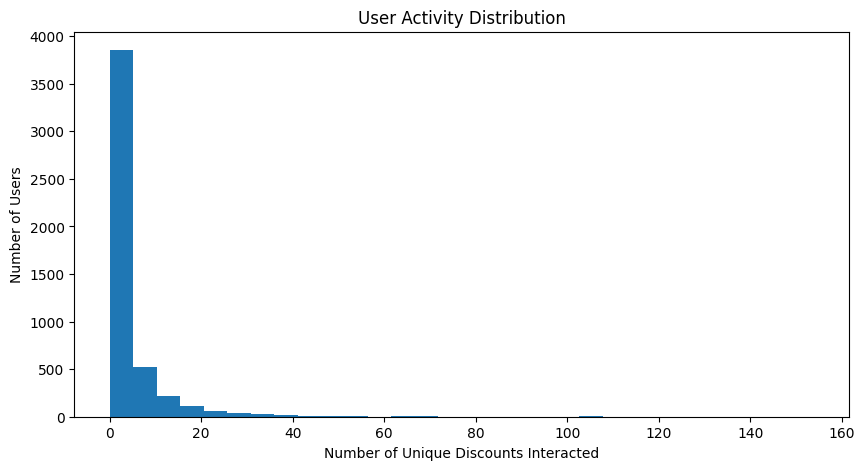

In [57]:
plt.figure(figsize=(10, 5))

plt.hist(
    all_users_activity["unique_discounts_interacted"],
    bins=30
)

plt.title("User Activity Distribution")
plt.xlabel("Number of Unique Discounts Interacted")
plt.ylabel("Number of Users")
plt.show()

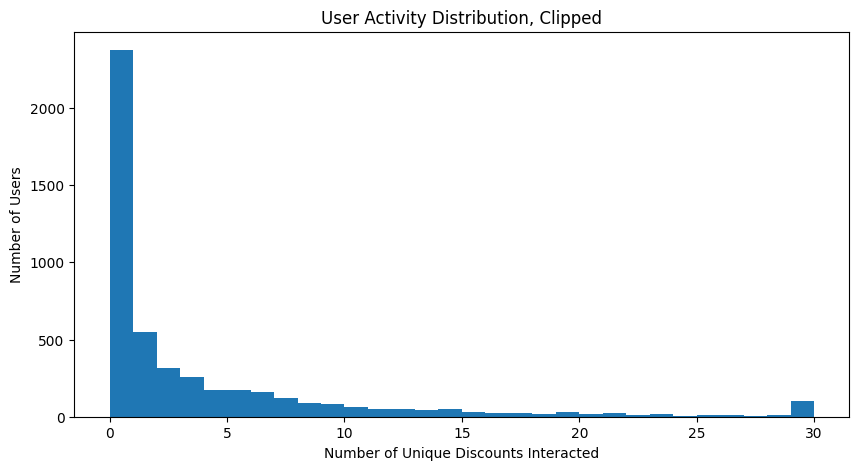

In [58]:
plt.figure(figsize=(10, 5))

plt.hist(
    all_users_activity["unique_discounts_interacted"].clip(upper=30),
    bins=30
)

plt.title("User Activity Distribution, Clipped")
plt.xlabel("Number of Unique Discounts Interacted")
plt.ylabel("Number of Users")
plt.show()

In [59]:
user_roles = users_df[["id", "role_id"]].copy()

user_roles = user_roles.rename(columns={
    "id": "user_id",
    "role_id": "user_role_id"
})

In [60]:
user_roles

,user_id,user_role_id
0,1814,3
1,1828,3
2,2959,3
3,3266,3
4,5033,3
...,...,...
4886,987,3
4887,5402,3
4888,5495,3
4889,2781,4


In [61]:
role_names = roles_df[["id", "name"]].copy()

role_names = role_names.rename(columns={
    "id": "user_role_id",
    "name": "role_name"
})
role_names

,user_role_id,role_name
0,1,System administrator
1,2,HR department employee
2,3,Company employee
3,4,HR department lead
4,5,Non-employee user
5,6,Guest user


In [62]:
discount_categories = category_discount_df[['discount_id','category_id']].copy()
discount_categories.head()

,discount_id,category_id
0,1,1
1,2,1
2,3,3
3,4,2
4,5,1


In [63]:
category_names = categories_df[['id','title']].copy()

category_names = category_names.rename(columns={
    'id':'category_id',
    'title':'category_name'  
})
category_names.head()

,category_id,category_name
0,1,Еда
1,2,Спорт
2,3,Красота и здоровье
3,4,Детям
4,5,Обучение


In [64]:
interactions_with_context = interactions_clean.merge(user_roles,on='user_id',how='left')
interactions_with_context = interactions_with_context.merge(role_names,on='user_role_id',how='left')
interactions_with_context = interactions_with_context.merge(discount_categories,on='discount_id',how='left')
interactions_with_context = interactions_with_context.merge(category_names,on='category_id',how='left')
interactions_with_context.head()

,user_id,discount_id,event_type,event_time,interaction_weight,source_table,location_id,role_id,user_role_id,role_name,category_id,category_name
0,1535,17,SHOW_AT_LOCATION,2025-01-16 15:18:53.386,0.1,discount_button_click_statistics,16.0,3.0,3,Company employee,1,Еда
1,9,522,SHOW_AT_LOCATION,2025-01-16 15:39:03.441,0.1,discount_button_click_statistics,16.0,3.0,3,Company employee,4,Детям
2,1455,5,SHOW_AT_LOCATION,2025-01-16 17:59:54.167,0.1,discount_button_click_statistics,16.0,3.0,3,Company employee,1,Еда
3,1455,2,SHOW_AT_LOCATION,2025-01-16 18:00:05.394,0.1,discount_button_click_statistics,16.0,3.0,3,Company employee,1,Еда
4,1418,11,SHOW_AT_LOCATION,2025-01-16 19:02:26.925,0.1,discount_button_click_statistics,16.0,3.0,3,Company employee,9,Магазины


In [65]:
interactions_with_context[['role_name','category_name']].isna().sum()

role_name        0
category_name    0
dtype: int64

In [66]:
role_category_matrix = pd.pivot_table(
    interactions_with_context,
    index='role_name',
    columns='category_name',
    values='user_id',
    aggfunc='count',
    fill_value=0
    
)
role_category_matrix

category_name,Авто,Детям,Для животных,Дом и бытовые услуги,Другое,Еда,Красота и здоровье,Магазины,Обучение,Путешествия,Развлечения и праздники,Спорт
role_name,,,,,,,,,,,,
Company employee,548,588,1292,1314,1004,11632,2362,4942,1299,1093,1604,2587
Guest user,0,7,1,3,0,5,6,14,2,1,5,5
HR department employee,46,154,98,193,176,1082,540,623,404,112,361,419
HR department lead,9,22,7,37,17,258,159,97,26,42,70,73
Non-employee user,31,24,76,117,69,761,122,257,66,67,97,154
System administrator,0,0,0,2,0,4,0,3,0,0,0,0


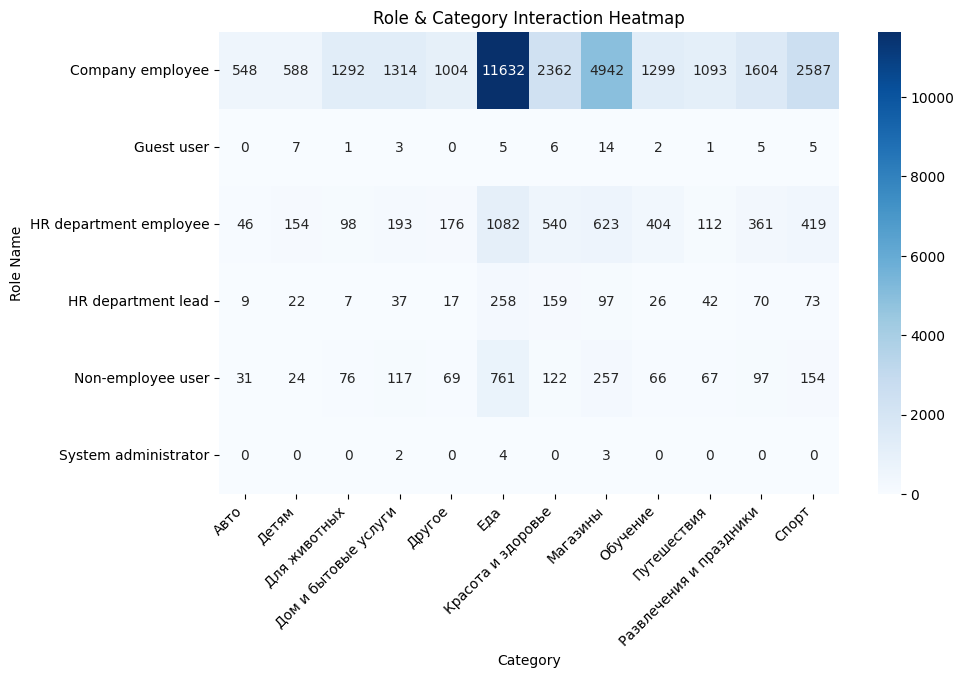

In [67]:
plt.figure(figsize=(10,6))
sns.heatmap(role_category_matrix,
            annot=True,
            fmt='.0f',
            cmap='Blues')

plt.title('Role & Category Interaction Heatmap')
plt.xlabel('Category')
plt.ylabel('Role Name')
plt.xticks(rotation=45,ha='right')
plt.show()

### Heatmap Correlation

In [68]:
discount_event_features = (
    interactions_clean.pivot_table(
        index='discount_id',
        columns='event_type',
        values='user_id',
        aggfunc='count',
        fill_value=0
    ).reset_index())

In [69]:

discount_event_features.head()

event_type,discount_id,DISLIKE,FAVOURITE,GET_A_PROMOCODE,LIKE,OPEN_CARD,SHOW_AT_LOCATION
0,1,0,4,2,7,15,6
1,2,0,58,534,45,502,18
2,3,0,1,0,1,1,3
3,4,0,6,6,7,30,7
4,5,2,69,661,56,318,14


In [70]:
discount_scores = (
    interactions_clean
    .groupby("discount_id")
    .agg(
        total_interactions=("user_id", "size"),
        weighted_score=("interaction_weight", "sum"),
        unique_users=("user_id", "nunique")
    )
    .reset_index()
)

discount_scores.head()

,discount_id,total_interactions,weighted_score,unique_users
0,1,34,46.1,23
1,2,1157,1587.4,502
2,3,6,7.6,5
3,4,56,66.7,28
4,5,1120,1856.8,503


In [71]:
discount_corr_features = discount_event_features.merge(
    discount_scores,
    on="discount_id",
    how="left"
)

discount_corr_features.head()

,discount_id,DISLIKE,FAVOURITE,GET_A_PROMOCODE,LIKE,OPEN_CARD,SHOW_AT_LOCATION,total_interactions,weighted_score,unique_users
0,1,0,4,2,7,15,6,34,46.1,23
1,2,0,58,534,45,502,18,1157,1587.4,502
2,3,0,1,0,1,1,3,6,7.6,5
3,4,0,6,6,7,30,7,56,66.7,28
4,5,2,69,661,56,318,14,1120,1856.8,503


In [72]:
corr_input = discount_corr_features.drop(columns=["discount_id"])

corr_matrix = corr_input.corr()

corr_matrix

,DISLIKE,FAVOURITE,GET_A_PROMOCODE,LIKE,OPEN_CARD,SHOW_AT_LOCATION,total_interactions,weighted_score,unique_users
DISLIKE,1.000000,0.205456,0.220696,0.240686,0.220926,0.150988,0.249010,0.226120,0.273559
FAVOURITE,0.205456,1.000000,0.892561,0.857725,0.749418,0.337028,0.916089,0.935903,0.900088
GET_A_PROMOCODE,0.220696,0.892561,1.000000,0.881947,0.696147,0.201553,0.930448,0.989825,0.881872
LIKE,0.240686,0.857725,0.881947,1.000000,0.741914,0.351515,0.906152,0.916839,0.876231
OPEN_CARD,0.220926,0.749418,0.696147,0.741914,1.000000,0.240229,0.901054,0.769525,0.919401
SHOW_AT_LOCATION,0.150988,0.337028,0.201553,0.351515,0.240229,1.000000,0.327611,0.254839,0.334773
total_interactions,0.249010,0.916089,0.930448,0.906152,0.901054,0.327611,1.000000,0.966718,0.981925
weighted_score,0.226120,0.935903,0.989825,0.916839,0.769525,0.254839,0.966718,1.000000,0.929046
unique_users,0.273559,0.900088,0.881872,0.876231,0.919401,0.334773,0.981925,0.929046,1.000000


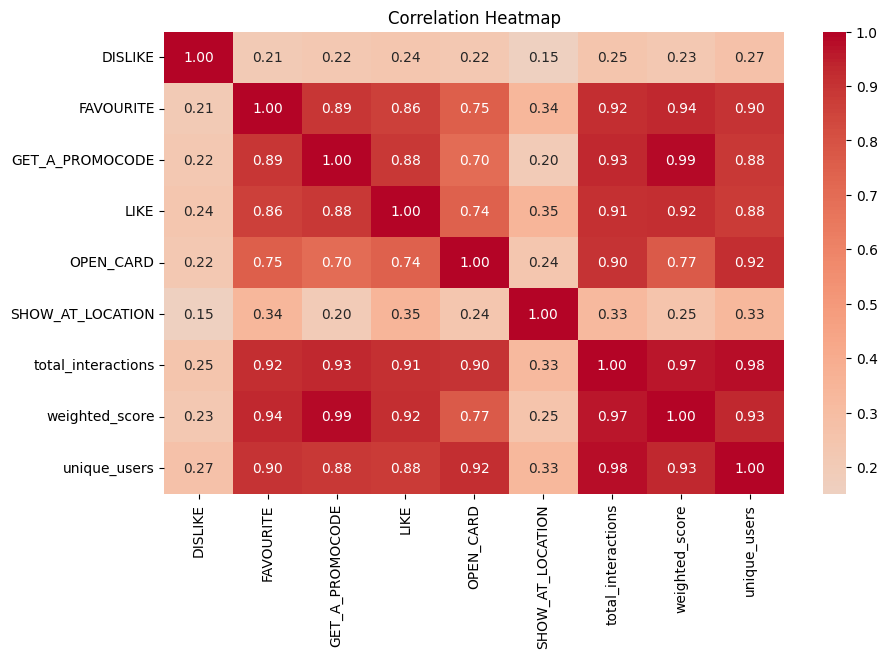

In [73]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.show()

In [74]:
interactions_clean.to_csv('../data/raw/interaction_clean.csv',index=False)